In [1]:
#import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [30]:
#reading file
df = pd.read_csv("C:\D_Drive\Reshma\MITSDE\Kagdata\prjexerc\stock_data.csv",
                 parse_dates=True, index_col="Date")
df.head()




<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\reshm\AppData\Local\Temp\ipykernel_25880\4042176527.py:2: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("C:\D_Drive\Reshma\MITSDE\Kagdata\prjexerc\stock_data.csv",


,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


In [31]:
#cleaning data
#drop column that are not important for visualization
df.drop(columns='Unnamed: 0', inplace =True)
df.head()

KeyError: "['Unnamed: 0'] not found in axis"

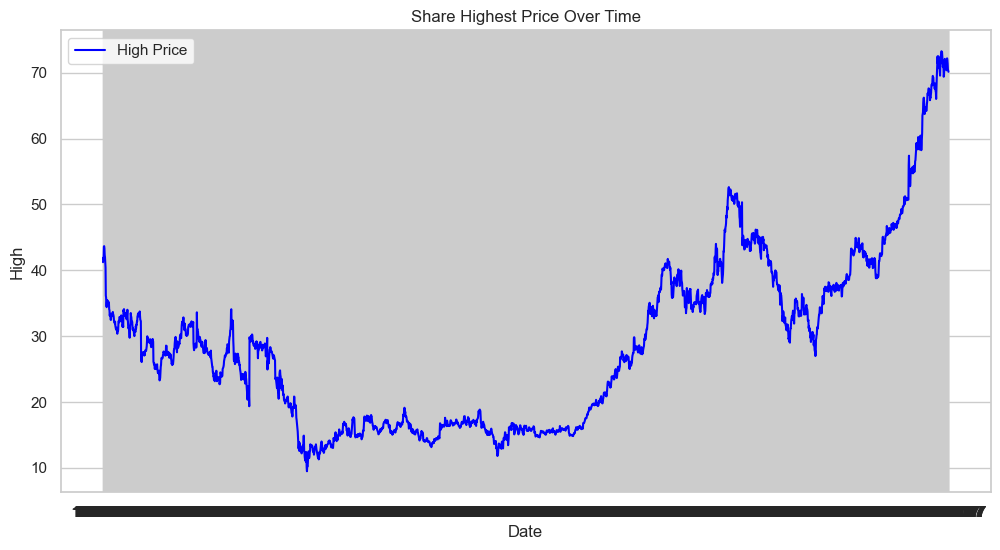

In [29]:
#ploting high stock prices
#Since the volume column is of continuous data type we will use line graph to visualize it.
sns.set(style="whitegrid") 

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='High', label='High Price', color='blue')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Share Highest Price Over Time')

plt.show()

C:\Users\reshm\AppData\Local\Temp\ipykernel_25880\511528437.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_resampled = df.resample('M').mean(numeric_only=True)


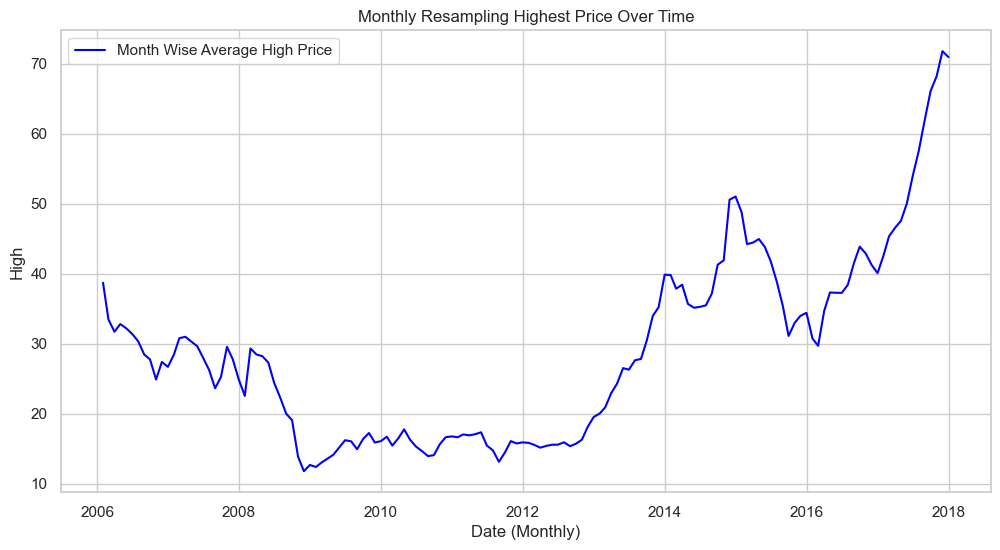

In [33]:
#Resampling Data
#resampling method which provide a clearer view of trends and patterns

df_resampled = df.resample('M').mean(numeric_only=True) 

sns.set(style="whitegrid") 

plt.figure(figsize=(12, 6))  
sns.lineplot(data=df_resampled, x=df_resampled.index, y='High', 
             label='Month Wise Average High Price', color='blue')

plt.xlabel('Date (Monthly)')
plt.ylabel('High')
plt.title('Monthly Resampling Highest Price Over Time')

plt.show()

'Date' is already the index or not present in the DataFrame.


<Figure size 1200x600 with 0 Axes>

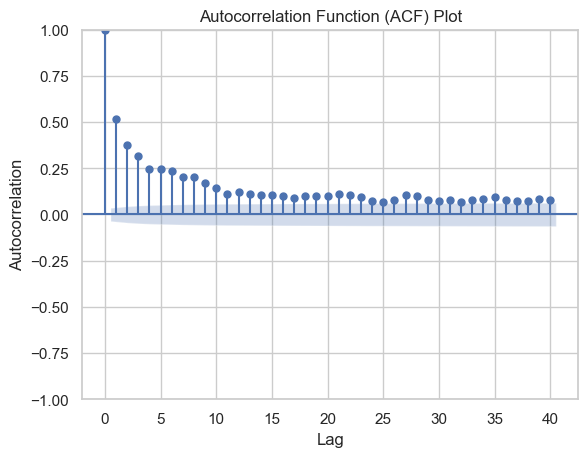

In [35]:
#detecting seasonality with autocorrrelation
#will detect Seasonality using the autocorrelation function (ACF) plot. Peaks at regular intervals in the ACF plot suggest the presence of seasonality.

if 'Date' not in df.columns:
    print("'Date' is already the index or not present in the DataFrame.")
else:
    df.set_index('Date', inplace=True)

plt.figure(figsize=(12, 6))
plot_acf(df['Volume'], lags=40) 
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF) Plot')
plt.show()






In [37]:
#there is no seasonality in our data
# will test stationarity for ADF test




from statsmodels.tsa.stattools import adfuller

result = adfuller(df['High'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])


ADF Statistic: 0.7671404880535936
p-value: 0.9910868050318213
Critical Values: {'1%': -3.4325316347197403, '5%': -2.862503905260741, '10%': -2.5672831121111113}


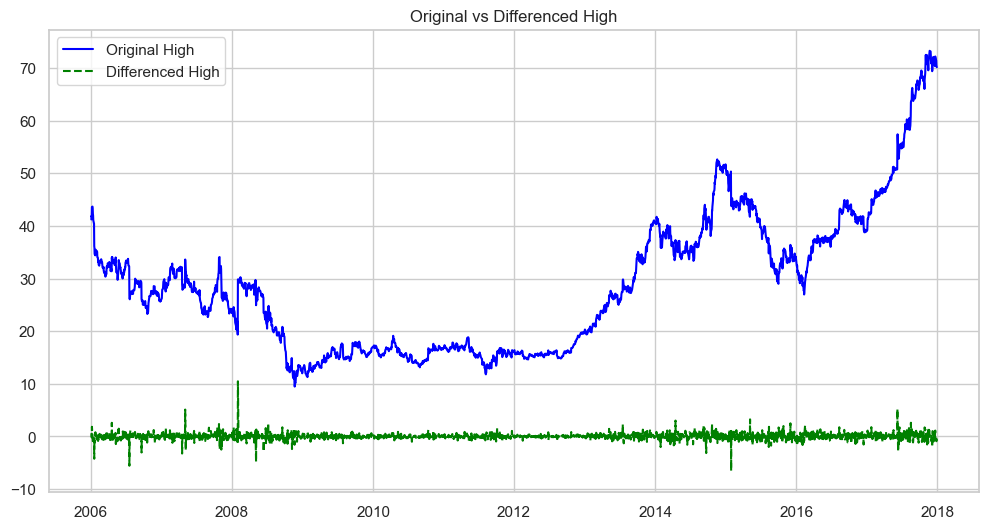

In [39]:
#Based on the ADF Statistic we accept the null hypothesis and check that the data does not appear to be stationary according to the Augmented Dickey-Fuller test.
#This suggests that differencing or other transformations may be needed to achieve stationarity before applying certain time series models.

#differencing to achieve stationarity
#Differencing involves subtracting the previous observation from the current observation to remove trends or seasonality.


df['high_diff'] = df['High'].diff()

plt.figure(figsize=(12, 6))
plt.plot(df['High'], label='Original High', color='blue')
plt.plot(df['high_diff'], label='Differenced High', linestyle='--', color='green')
plt.legend()
plt.title('Original vs Differenced High')
plt.show()





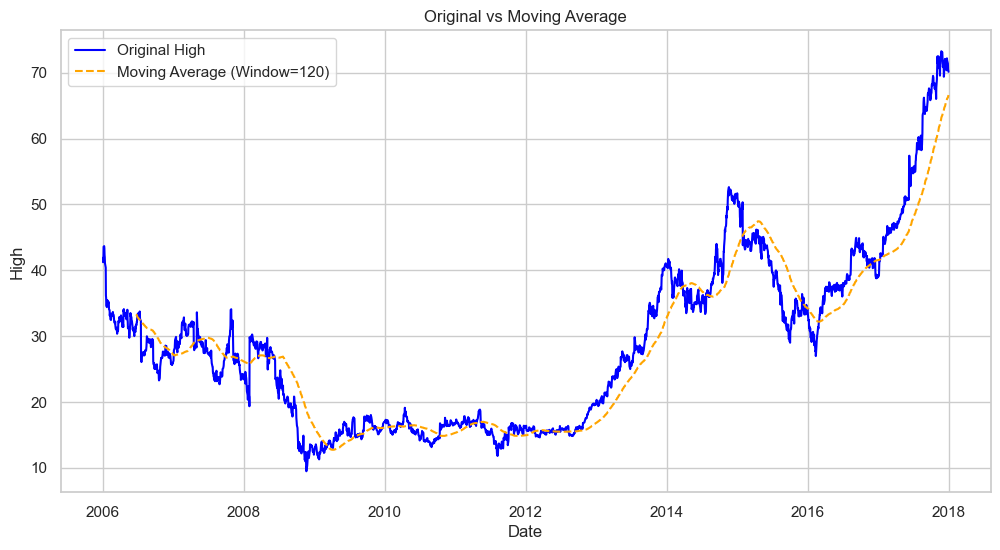

In [41]:
#smoothing data with moving average
#df['High'].diff(): helps in calculating the difference between consecutive values in the High column. This differencing operation is used to transform a time series into a new series that represents the changes between consecutive observations.

window_size = 120
df['high_smoothed'] = df['High'].rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))

plt.plot(df['High'], label='Original High', color='blue')
plt.plot(df['high_smoothed'], label=f'Moving Average (Window={window_size})', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Original vs Moving Average')
plt.legend()
plt.show()


In [43]:
#This calculates the moving average of the High column with a window size of 120(A quarter), creating a smoother curve in the high_smoothed series. The plot compares the original High values with the smoothed version


#Original data vs differenced data
#Printing the original and differenced data side by side we get:

df_combined = pd.concat([df['High'], df['high_diff']], axis=1)

print(df_combined.head())


             High  high_diff
Date                        
2006-01-03  41.22        NaN
2006-01-04  41.90       0.68
2006-01-05  41.73      -0.17
2006-01-06  43.57       1.84
2006-01-09  43.66       0.09


In [45]:
#Hence the high_diff column represents the differences between consecutive high values. The first value of high_diff is NaN because there is no previous value to calculate the difference.

#As there is a NaN value we will drop that proceed with our test:

df.dropna(subset=['high_diff'], inplace=True)
df['high_diff'].head()

Date
2006-01-04    0.68
2006-01-05   -0.17
2006-01-06    1.84
2006-01-09    0.09
2006-01-10   -0.32
Name: high_diff, dtype: float64

In [47]:
#conduct the ADF test:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['high_diff'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -12.14836747834328
p-value: 1.5912766134146188e-22
Critical Values: {'1%': -3.4325316347197403, '5%': -2.862503905260741, '10%': -2.5672831121111113}


In [ ]:
#Based on the ADF Statistic we reject the null hypothesis and conclude that we have enough evidence to reject the null hypothesis

